In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

COLOR_BASE = 'thistle'
COLOR_ACCENT = 'indigo'

# SQL query

In [ ]:
auth.authenticate_user()

client = bigquery.Client(project="data-analytics-mate")

sql_query = """
SELECT
  s.date,
  sp.ga_session_id as session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.medium as traffic_source,
  sp.channel,
  a.id as account_id,
  a.is_verified as email_verified,
  a.is_unsubscribed as unsubscribed,
  p.category,
  p.name as product_name,
  p.price,
  p.short_description as product_description

FROM `data-analytics-mate.DA.session` s
LEFT JOIN `data-analytics-mate.DA.session_params` sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
  ON acs.ga_session_id = s.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` a
  ON acs.account_id = a.id
LEFT JOIN `data-analytics-mate.DA.order` o
  ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
  ON o.item_id = p.item_id
"""

df = client.query(sql_query).to_dataframe()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 349545 non-null  dbdate 
 1   session_id           349545 non-null  Int64  
 2   continent            349545 non-null  object 
 3   country              349545 non-null  object 
 4   device               349545 non-null  object 
 5   browser              349545 non-null  object 
 6   mobile_model_name    349545 non-null  object 
 7   operating_system     349545 non-null  object 
 8   language             235279 non-null  object 
 9   traffic_source       349545 non-null  object 
 10  channel              349545 non-null  object 
 11  account_id           27945 non-null   Int64  
 12  email_verified       27945 non-null   Int64  
 13  unsubscribed         27945 non-null   Int64  
 14  category             33538 non-null   object 
 15  product_name     

# Data cleaning

In [ ]:
print(df.isna().sum())
print(df.isna().sum() / df.shape[0] * 100)

# Fill in the missing values for language
df['language'] = df['language'].fillna('UNKNOWN')

# Change data types
df['session_id'] = df['session_id'].astype(str)
df['date'] = pd.to_datetime(df['date'])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

# Final check
print(df.isna().sum() / df.shape[0] * 100)
df.info()


date                        0
session_id                  0
continent                   0
country                     0
device                      0
browser                     0
mobile_model_name           0
operating_system            0
language               114266
traffic_source              0
channel                     0
account_id             321600
email_verified         321600
unsubscribed           321600
category               316007
product_name           316007
price                  316007
product_description    316007
dtype: int64
date                    0.000000
session_id              0.000000
continent               0.000000
country                 0.000000
device                  0.000000
browser                 0.000000
mobile_model_name       0.000000
operating_system        0.000000
language               32.689925
traffic_source          0.000000
channel                 0.000000
account_id             92.005321
email_verified         92.005321
unsubscribed      

На цьому етапі проведено базову підготовку датасету до аналізу:
- Порожні значення в колонці "language" замінено на "UNKNOWN".
- Колонку "date" приведено до формату "datetime" для подальшого аналізу дат.
- Колонку "session_id" переформатовано в текст.
- Датасет перевірено на наявність однакових рядків.

# General Dataset Overview


In [ ]:
df.info()

unique_sessions = df['session_id'].nunique()
print(f"\nNumber of unique sessions: {unique_sessions}")

unique_accounts = df['account_id'].nunique()
print(f"Number of unique accounts: {unique_accounts}")

unique_countries = df['country'].nunique()
print(f"Number of unique countries: {unique_countries}")


min_date = df['date'].min()
max_date = df['date'].max()
months_count = df['date'].dt.to_period('M').nunique()
print(f"\nAnalysis period: from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Duration: {months_count} months")

print("\nPercent of missing values ​​by column")
missing_values = df.isnull().sum() / df.shape[0] * 100
print(missing_values[missing_values > 0].sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 349545 non-null  datetime64[ns]
 1   session_id           349545 non-null  object        
 2   continent            349545 non-null  object        
 3   country              349545 non-null  object        
 4   device               349545 non-null  object        
 5   browser              349545 non-null  object        
 6   mobile_model_name    349545 non-null  object        
 7   operating_system     349545 non-null  object        
 8   language             349545 non-null  object        
 9   traffic_source       349545 non-null  object        
 10  channel              349545 non-null  object        
 11  account_id           27945 non-null   Int64         
 12  email_verified       27945 non-null   Int64         
 13  unsubscribed  

### Висновки з загального огляду

- Датасет містить інформацію про майже 350 тисяч унікальних сесій за 3 повні місяці (з листопада 2020 до січня 2021). Географія дуже широка, трафік надходить зі 108 країн.
- Переважна більшість трафіку є гостьовою, 92% сесій відбуваються без авторизації або реєстрації, це ми можемо побачити по відсутньому "account_id".
- Близько 90% трафіку - це користувачі, які гортають сторінки, але не доходять до етапу покупки. Конверсія складає близько 10%. На це вказують заповнені колонки "price" та "product_name".

# Acquisition and Traffic

In [ ]:
channel_sessions_vs_revenue = df.groupby('channel').agg(
    session = ('session_id', 'nunique'),
    revenue = ('price', 'sum')
)

total_sessions = df['session_id'].nunique()
total_revenue = df['price'].sum()

channel_sessions_vs_revenue['session'] = channel_sessions_vs_revenue['session'] / total_sessions * 100
channel_sessions_vs_revenue['revenue'] = channel_sessions_vs_revenue['revenue'] / total_revenue * 100

print(channel_sessions_vs_revenue)

device_sessions_vs_revenue = df.groupby('device').agg(
    session = ('session_id', 'nunique'),
    revenue = ('price', 'sum')
)

total_sessions = df['session_id'].nunique()
total_revenue = df['price'].sum()

device_sessions_vs_revenue['session'] = device_sessions_vs_revenue['session'] / total_sessions * 100
device_sessions_vs_revenue['revenue'] = device_sessions_vs_revenue['revenue'] / total_revenue * 100

print(device_sessions_vs_revenue)

                  session    revenue
channel                             
Direct          23.282267  23.442345
Organic Search  35.596275  35.760189
Paid Search     26.989658  26.620546
Social Search    7.985810   7.919827
Undefined        6.145990   6.257093
           session    revenue
device                       
desktop  58.484315  59.002245
mobile   39.270194  38.734924
tablet    2.245491   2.262831


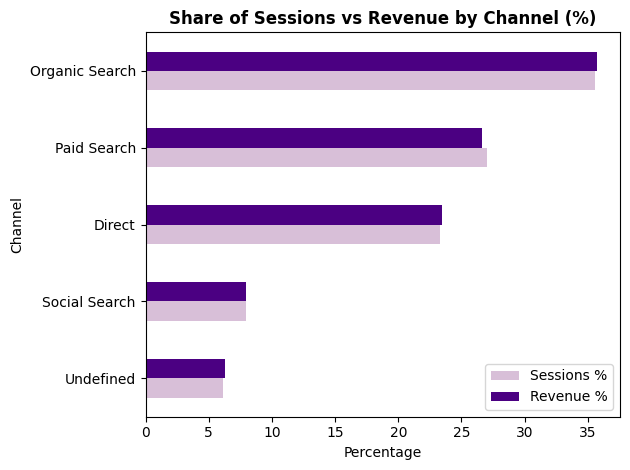

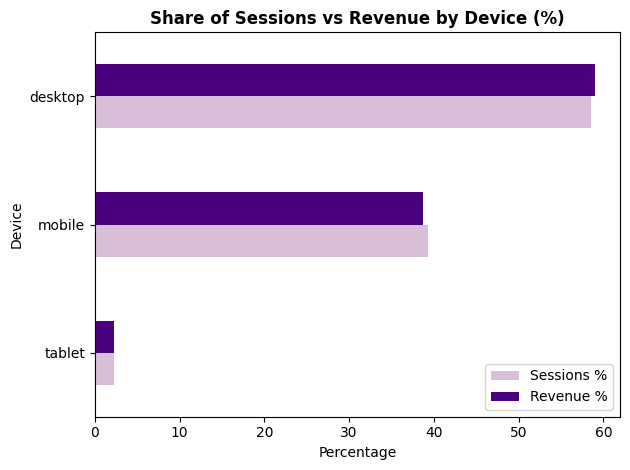

In [ ]:
barh1 = channel_sessions_vs_revenue.sort_values('revenue', ascending=True).plot(
    kind='barh',
    color=[COLOR_BASE, COLOR_ACCENT]
)
plt.title('Share of Sessions vs Revenue by Channel (%)', fontsize=12, fontweight='bold')
plt.xlabel('Percentage', fontsize=10)
plt.ylabel('Channel', fontsize=10)
plt.legend(['Sessions %', 'Revenue %'])
plt.tight_layout()
plt.show()


barh2 = device_sessions_vs_revenue.sort_values('revenue', ascending=True).plot(
    kind='barh',
    color=[COLOR_BASE, COLOR_ACCENT]
)
plt.title('Share of Sessions vs Revenue by Device (%)', fontsize=12, fontweight='bold')
plt.xlabel('Percentage', fontsize=10)
plt.ylabel('Device', fontsize=10)
plt.legend(['Sessions %', 'Revenue %'])
plt.tight_layout()
plt.show()

Основне джерело продажів - це органічний пошук, який генерує понад 35% трафіку та доходу. Десктоп є основним пристроєм, приносячи майже 60% сесій та продажів.

**Аналітична аномалія.** В цьому датасеті ми бачимо ідеальний паритет між часткою залученого трафіку та часткою згенерованого доходу в розрізі всіх каналів та девайсів (наприклад, 58% сесій з десктопу дають 59% доходу). У реальному e-commerce зазвичай мобільний трафік дає багато сесій і низька конверсію, а десктоп навпаки - менше сесій, але вищий середній чек і конверсія.

З точки зору маркетингу, така ідеальна пропорція означала б, що якість трафіку та прохідність воронки продажів є абсолютно однаковими незалежно від того, з якого пристрою чи каналу прийшов клієнт. Відсутність будь-якого відхиленя при покупці з мобільних пристроїв прямо вказує на те, що дані не є реальними.

# Market and Product Fit

In [ ]:
# top 5 countries
region_analysis = pd.pivot_table(
    data=df,
    index='country',
    values=['price', 'session_id'],
    aggfunc={'price': 'sum', 'session_id': 'nunique'}
)

region_analysis = region_analysis.sort_values(by='price', ascending=False)

print(region_analysis.head(5))

                     price  session_id
country                               
United States   13943553.9      153470
India            2809762.0       32763
Canada           2437921.0       25994
United Kingdom    938317.9       11003
France            710692.8        6958


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 349545 non-null  datetime64[ns]
 1   session_id           349545 non-null  object        
 2   continent            349545 non-null  object        
 3   country              349545 non-null  object        
 4   device               349545 non-null  object        
 5   browser              349545 non-null  object        
 6   mobile_model_name    349545 non-null  object        
 7   operating_system     349545 non-null  object        
 8   language             349545 non-null  object        
 9   traffic_source       349545 non-null  object        
 10  channel              349545 non-null  object        
 11  account_id           27945 non-null   Int64         
 12  email_verified       27945 non-null   Int64         
 13  unsubscribed  

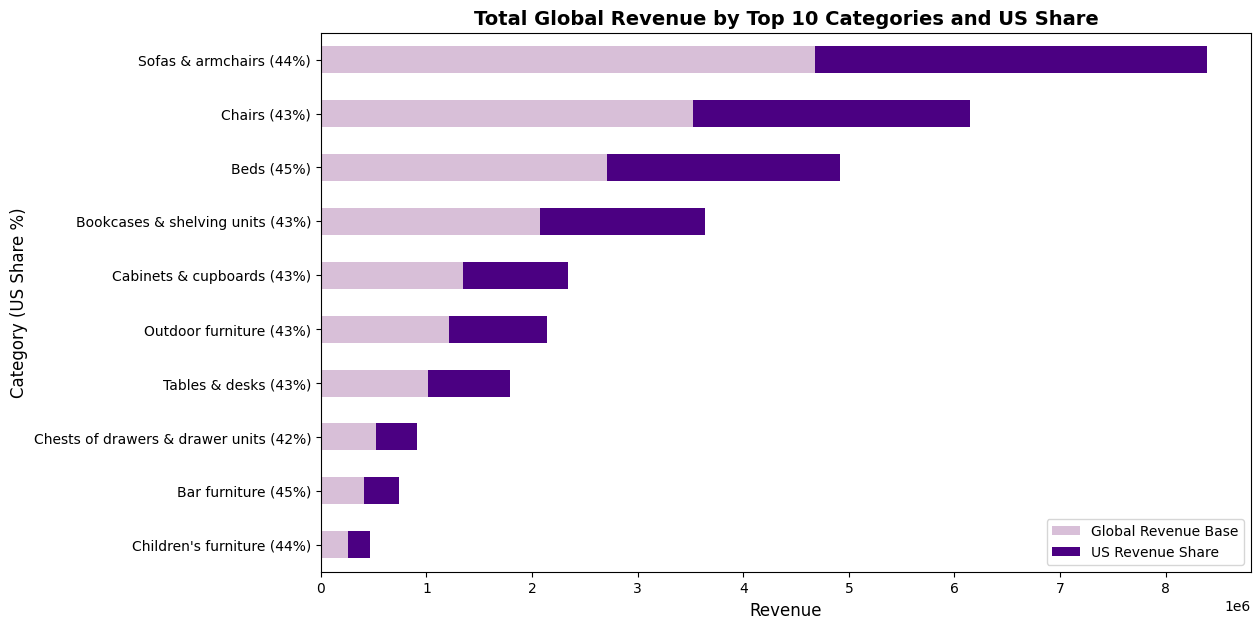

In [ ]:
df.info()

# Calculate global category performance metrics
global_category_metrics = pd.pivot_table(
    data=df,
    index='category',
    values=['price', 'session_id'],
    aggfunc={'price': 'sum', 'session_id': 'nunique'}
)
global_category_metrics = global_category_metrics.sort_values(by='price', ascending=False)

# Isolate US market data
df_us = df[df['country'] == 'United States']

# Calculate US category performance metrics
us_category_metrics = pd.pivot_table(
    data=df_us,
    index='category',
    values=['price', 'session_id'],
    aggfunc={'price': 'sum', 'session_id': 'nunique'}
)
us_category_metrics = us_category_metrics.sort_values(by='price', ascending=False)

# Merge global and US metrics for comparison
us_vs_global = pd.merge(
    global_category_metrics,
    us_category_metrics,
    on="category",
    how="inner",
    suffixes=('_world', '_us')
)

# Calculate US share of global revenue and sessions
us_vs_global['us_revenue_share_pct'] = round((us_vs_global['price_us'] / us_vs_global['price_world'] * 100), 0).astype(int)
us_vs_global['us_session_share_pct'] = round((us_vs_global['session_id_us'] / us_vs_global['session_id_world'] * 100), 0)

plot_data = us_vs_global.head(10).copy()

plot_data['price_other_world'] = plot_data['price_world'] - plot_data['price_us']

plot_data.index = plot_data.index + ' (' + plot_data['us_revenue_share_pct'].astype(str) + '%)'
plot_data = plot_data.sort_values(by='price_world', ascending=True)

ax = plot_data[['price_other_world', 'price_us']].plot(
    kind='barh',
    stacked=True,
    color=[COLOR_BASE, COLOR_ACCENT],
    figsize=(12, 7),
)

plt.title('Total Global Revenue by Top 10 Categories and US Share', fontsize=14, fontweight='bold')
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Category (US Share %)', fontsize=12)
plt.legend(['Global Revenue Base', 'US Revenue Share'])
plt.show()

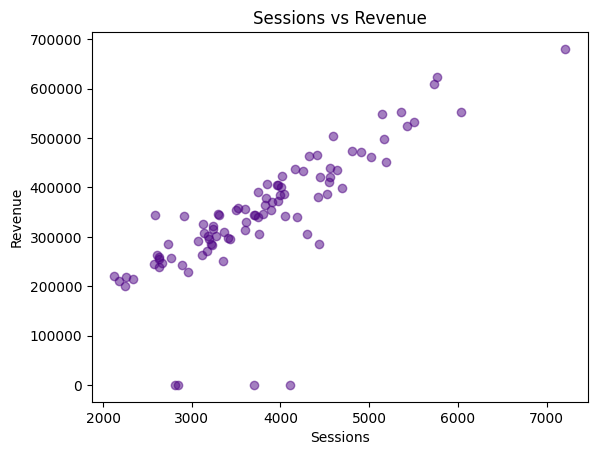

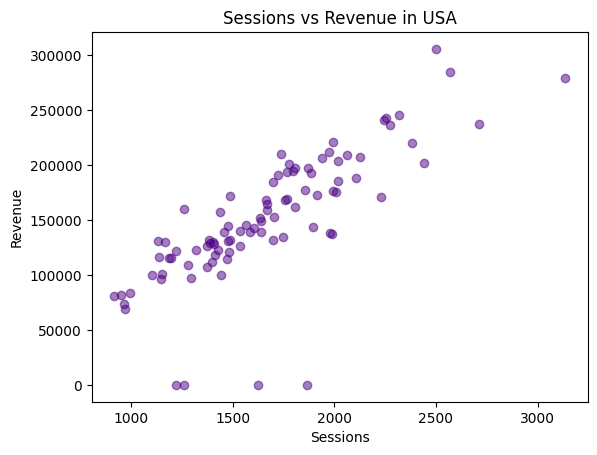

Pearson Correlation for world: p-value: 6.483532312080735e-21
Pearson Correlation for USA: p-value: 3.472993492148193e-20


In [ ]:
# sessions vs revenue_world
date_sessions_vs_revenue_world = df.groupby('date').agg(
    session = ('session_id', 'nunique'),
    revenue = ('price', 'sum')
)

# sessions vs revenue_us
date_sessions_vs_revenue_us = df[df['country'] == 'United States'].groupby('date').agg(
    session=('session_id', 'nunique'),
    revenue=('price', 'sum')
)

plt.scatter(date_sessions_vs_revenue_world['session'], date_sessions_vs_revenue_world['revenue'], alpha=0.5, color=COLOR_ACCENT)
plt.title('Sessions vs Revenue')
plt.xlabel('Sessions')
plt.ylabel('Revenue')
plt.show()

plt.scatter(date_sessions_vs_revenue_us['session'], date_sessions_vs_revenue_us['revenue'], alpha=0.5, color=COLOR_ACCENT)
plt.title('Sessions vs Revenue in USA')
plt.xlabel('Sessions')
plt.ylabel('Revenue')
plt.show()

from scipy.stats import pearsonr

# Calculate Pearson correlation
r_world, p_val_world = pearsonr(date_sessions_vs_revenue_world['session'], date_sessions_vs_revenue_world['revenue'])
print(f"Pearson Correlation for world: p-value: {p_val_world}")

r_us, p_val_us = pearsonr(date_sessions_vs_revenue_us['session'], date_sessions_vs_revenue_us['revenue'])
print(f"Pearson Correlation for USA: p-value: {p_val_us}")

Абсолютним лідером за обсягом продажів, а також за кількістю відвідувачів на сайт є США. Аналіз показує, що структура попиту в США ідеально повторює загальносвітову тенденцію -  у кожній топ-10 категорій товарів частка продажів на американському ринку стабільно тримається на рівні 42-46%.
З точки зору бізнесу, це свідчить про відсутність потреби в локалізації асортименту. Глобальна товарна матриця повністю задовольняє потреби ключового ринку. Це дозволяє компанії використовувати єдину світову стратегію просування.

Для перевірки того, наскільки пропорційно зростають продажі при збільшенні кількості сесій, використано кореляцію Пірсона, через те, що це найкращий метод для пошуку лінійної залежності між двома кількісними метриками. Розрахунок показав p-value для обох змінних - США та всього світу - майже нуль (що значно менше за поріг 0.05). Це математично доводить, що зв'язок між кількістю візитів та доходом є не випадковим. Бізнес-модель гарно прогнозується, тому її легко масштабувати. Компанія може доволі безпечно збільшувати рекламні бюджети, через те, що новийц трафік буде стабільно конвертувати оборот.

**Аналітична аномалія.** Як і в першому блоці, ідеальний збіг пропорцій у всіх категоріях є нетиповим. У реальному ритейлі локальні ринки завжди мають відхилення у структурі попиту через конкурентне середовище або культурні особливості. Настільки рівномірний розподіл продажів додатково підтверджує штучне походження датасету.

# Retention and CRM

In [ ]:
auth_users = df.dropna(subset=['account_id'])
unsub_pct = (auth_users['unsubscribed'] == 1).mean() * 100
print(f"Percent of unsubscribed: {unsub_pct}%\n")

account_unsubscribed = df[df['unsubscribed'] == 1].groupby('account_id').agg(
    session=('session_id', 'nunique'),
    revenue=('price', 'sum')
)

account_subscribed = df[df['unsubscribed'] == 0].groupby('account_id').agg(
    session=('session_id', 'nunique'),
    revenue=('price', 'sum')
)

print("Averages for unsubscribed users")
print(account_unsubscribed.mean())

print("\nAverages for subscribed users")
print(account_subscribed.mean())

t_stat, p_value = stats.ttest_ind(account_unsubscribed['revenue'], account_subscribed['revenue'])
print(f"p-value: {p_value}")

Percent of unsubscribed: 16.94399713723385%

Averages for unsubscribed users
session     1.000000
revenue    91.176684
dtype: float64

Averages for subscribed users
session     1.00000
revenue    92.66682
dtype: float64
p-value: 0.8519036210636035


З бази авторизованих користувачів від розсилки відписалися 16.9%.
Порівняння показало, що відписані клієнти приносять в середньому 91.17 дол, підписані - 92.66 дол.
Проведений t-test видав p-value = 0.852, що значно перевищує поріг 0.05, а це значить різниця є статистично незначущою. Те, чи підписана людина на наші листи, математично ніяк не впливає на те, скільки вона витрачає.

**Аналітична аномалія**.
У базі авторизованих користувачів (майже 28 000 акаунтів) середня кількість сесій на одного клієнта за 3 місяці дорівнює рівно 1. Показник повернення на сайт відсутній повністю. Це черговий доказ синтетичної природи датасету, при його створенні просто не заклали логіку повторних візитів.

**Якби дані були реальними**.
Той факт, що відписка від листів не змінює поведінку клієнта, говорить про кризу email-маркетингу в компанії. Бізнес має базу контактів, але не заробляє на ній. Тож я рекомендую:
1. Проаналізувати воронку розсилок (як часто листи відкривають і чи клікають посилання). Якщо листи відкривають, але це не приносить грошей, значить проблема в самих текстах, нецікавих товарних пропозиціях або незрозумілих закликах до дії.
2. Замість листів варто спробувати інші інструменти для роботи з лояльною базою. Наприклад, пуш-повідомлення, персональні промокоди на другу покупку або систему бонусів, щоб стимулювати людей повертатися.

          channel  is_registered  sessions     revenue
0          Direct          False     74868   6885986.2
1          Direct           True      6514    608937.2
2  Organic Search          False    114390  10498822.1
3  Organic Search           True     10035    934329.5
4     Paid Search          False     86874   7870249.8
5     Paid Search           True      7467    640799.6
6   Social Search          False     25702   2326965.8
7   Social Search           True      2212    205139.9
8       Undefined          False     19766   1807188.7
9       Undefined           True      1717    193312.3


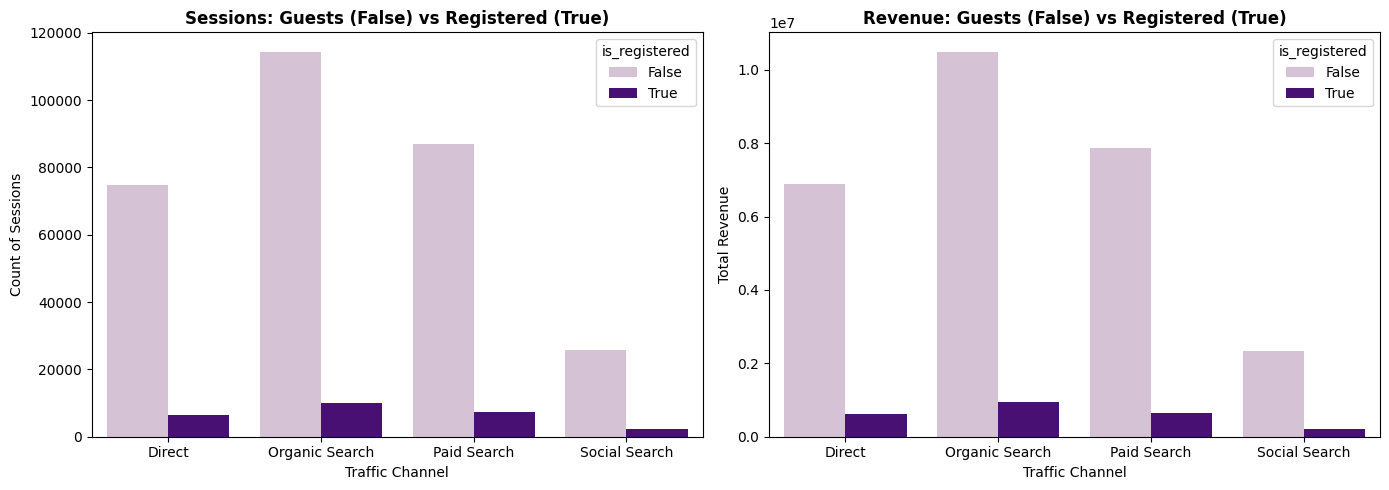

Average check of Registered: 928.63
Average check of Guests: 955.53
T-test p-value: 0.3023166395917663


In [ ]:
df['is_registered'] = df['account_id'].notna()

channel_registration_with_undef = df.groupby(['channel', 'is_registered']).agg(
    sessions=('session_id', 'nunique'),
    revenue=('price', 'sum')
).reset_index()

print(channel_registration_with_undef.sort_values(by=['channel', 'is_registered']))

channel_registration = channel_registration_with_undef[channel_registration_with_undef['channel'] != 'Undefined']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sessions
sns.barplot(data=channel_registration, x='channel', y='sessions', hue='is_registered',
            palette=[COLOR_BASE, COLOR_ACCENT], ax=axes[0])
axes[0].set_title('Sessions: Guests (False) vs Registered (True)', fontweight='bold')
axes[0].set_ylabel('Count of Sessions')
axes[0].set_xlabel('Traffic Channel')

# Revenue
sns.barplot(data=channel_registration, x='channel', y='revenue', hue='is_registered',
            palette=[COLOR_BASE, COLOR_ACCENT], ax=axes[1])
axes[1].set_title('Revenue: Guests (False) vs Registered (True)', fontweight='bold')
axes[1].set_ylabel('Total Revenue')
axes[1].set_xlabel('Traffic Channel')

plt.tight_layout()
plt.show()

# T-test
registered_revenue = df[df['is_registered'] == True]['price'].dropna()
guest_revenue = df[df['is_registered'] == False]['price'].dropna()

t_stat, p_val = stats.ttest_ind(registered_revenue, guest_revenue)

print(f"Average check of Registered: {registered_revenue.mean():.2f}")
print(f"Average check of Guests: {guest_revenue.mean():.2f}")
print(f"T-test p-value: {p_val}")

У всіх каналах співвідношення сесій гостей до авторизованих користувачів дуже схоже. Це неможливо в реальному житті, адже різні канали дають різний відсоток реєстрацій. Це ще раз підтверджує синтетичність датасету.

Більшу частку загального доходу генерують гості. При цьому різниця середних чеків при покупці у гостей - 955.53 дол та зареєстрованих - 928.63 дол мінімальна. Проведений Т-тест показав p-value 0.302 Це доводить, що ця різниця є статистично незначущою.

Сам факт реєстрації клієнта на сайті не приносить бізнесу жодної фінансової користі. Компанія ніяк не стимулювала авторизованих користувачів витрачати більше. Програма лояльності відсутня або не працює. Тож необхідно впроваджувати інструменти стимулювання додаткових покупок для авторизованих користувачів. Збирати базу контактів і не монетезувати її є неефективним використанням функціоналу на сайті.

# General conclusions

1. **Залучення та ринки**

Головне джерело доходу — гостьовий трафік з невеликими чеками, при цьому найефективніше працює органічний пошук.
США є ключовим ринком, але структура попиту там ідентичнатака сама, що і в усьму світі. Це говорить про те, що компанії не потрібно витрачати ресурси на локалізацію асортименту, глобальна товарна матриця працює скрізь однаково.
Розрахунок кореляції підтверджує чітку лінійну залежність між трафіком та доходом. Воронка залучення працює ідеально - збільшення рекламного бюджету пропорційно збільшуватиме продажі.

2. **Утримання та CRM**

Процеси роботи з існуючими клієнтами неефективні. Реєстрація на сайті чи підписка на розсилку не впливають на середній чек. Він майже однаковий як для гостей (неавторизованих користувачів), так і для авторизованих користувачів.
Компанія має базу з майже 28 тисяч контактів, але не пряцює з нею.
Рішення: поточний формат email-розсилок потрібно переглянути. Для стимулювання повторних покупок варто протестувати інші інструменти. Наприклад, push-повідомлення, персональні знижки для зареєстрованих користувачів, гейміфікацію тощо.

3. **Штучність даних**

З високою ймовірністтю датасет згенерований штучно. Про це свідчать три виявлені аналітичні аномалії:
   1. Ідеальні пропорції трафіку та доходу між різними девайсами (у реальності конверсія з мобільного та десктопу завжди буде різною)
   2. Рівномірний розподіл попиту на категорії товарів по всьому світу без жодних локальних відхилень (на прикладі США)
   3. Повна відсутність повернень на сайт. Всі майже 28 тисяч зареєстрованих користувачів мають рівно по одній сесії за 3 місяці.

In [ ]:
from google.colab import files

df.to_csv('ecommerce_cleaned_data.csv', index=False)
files.download('ecommerce_cleaned_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Visualization in Tableau

[View E-Commerce Performance & Data Audit dashboard on Tableau Public](https://public.tableau.com/views/Portfolio1_17779263405390/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)